In [1]:
import numpy as np
import starsim as ss
import sciris as sc
import pandas as pd
from enum import IntEnum, auto
import seaborn as sns
from pathlib import Path
import pickle

/Users/nparke19/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import starsim as ss
import sciris as sc
import pandas as pd
from enum import IntEnum, auto
import seaborn as sns
from pathlib import Path
import pickle
from collections import defaultdict


###### function to run simulations of multiple location datasets

###### Arguments:
#### district_file: file of district names
### location_data_folder: path/folder name with location date (i.e. "Actual_loc_10")
### output_name: desired name for output. Need to have .pkl at end because it's a pickle object (i.e. "Lusaka_COVID_sims.pkl")
### num_people: number of people in simulation
### sim_length: end day of simulation (i.e. 299)
### duration_of_exp: duration of exposure period as a distribution (i.e. ss.lognorm_ex(mean=0.4, std=0.3))
### beta_val: beta value of pathogen (i.e. 0.0577)
### duration_of_infectiousness: duration of infectious period as a distribution (i.e. ss.lognorm_ex(mean=0.4, std=0.3))


def starsim_sim_function(district_file, location_data_folder, output_name, num_people, sim_length, duration_of_exp, beta_val, duration_of_infectiousness): 
    
    ### first, define all arguments
    district_file = district_file
    location_data_folder = location_data_folder
    output_name = output_name
    num_people = num_people
    sim_length = sim_length
    duration_of_exp = duration_of_exp
    beta_val = beta_val
    duration_of_infectiousness = duration_of_infectiousness

    ### create LocationDemographics class to allow for dynamically updating location data
    class LocationDemographics(ss.Demographics):
        """ Track and update each person's location at every timestep """
        def __init__(self, location_dataset, locations=None, pars=None, **kwargs):
            """
            Initialize locations and movement probabilities.

            Args:
                locations (list): List of possible locations.
                movement_probs (dict): Dictionary defining movement probabilities between locations.
            """
            super().__init__()
            
            self.define_pars(
                locations=locations , 
                location_dataset=location_dataset
                
            )
            self.update_pars(pars, **kwargs)
            
            return
        
        def init_pre(self, sim):
            """ 
            Initialize the location for each person at the start of the simulation 
            """
            super().init_pre(sim)
            people = self.sim.people
            loc_data = self.pars.location_dataset
            print("Number of people:", len(self.sim.people))


            people.location = loc_data[(loc_data["step"] == 0)]["location"].values
            print("peoples.location:", people.location)
            
            return

            
        
        def step(self):
            """ Update each person's location at every timestep """
            sim = self.sim
            people = self.sim.people
            loc_data = self.pars.location_dataset

            if self.ti % 5 == 0:
                print("time step", self.ti)

            
            current_step_data = loc_data[loc_data["step"] == self.ti][["uid", "location"]]


            location_array = current_step_data["location"].values
            people.location[:] = location_array
            
            return

        def init_results(self):
            """ Initialize tracking of locations over time """
            super().init_results()
            for loc in self.pars.locations:
                self.define_results(ss.Result(f'num_in_{loc}', dtype=int, label=f'People in {loc}'))
            return
        
        def update_results(self):
            """ Store location data at each timestep """
            people = self.sim.people
            for loc in self.pars.locations:
                self.results[f'num_in_{loc}'][self.ti] = np.sum(people.location == loc)
            return


    ### set the parameters of the simulation. The length of the simulation is adjustable.     
    pars = sc.objdict(total_pop = 10e6, n_agents = 20000, start = 0, stop= sim_length, unit = 'day',
                    verbose = 0)

    n_people = num_people


    ### load in the district data and set the LOCATION variable, which assigns a unqiue number to each location 
    districts = pd.read_csv(district_file)

    district_names = districts["District"].tolist()

    LOCATION = IntEnum("LOCATION", {name.upper().replace(" ", "_"): i for i, name in enumerate(district_names)})



    ### create a CustomNet class which defines the network structure manually
    class CustomNet(ss.Network):
        def __init__(self, contact_dict):
            super().__init__()
            self.contact_dict = contact_dict

        def step(self):
            contacts = self.contact_dict[self.ti]
            self.edges.p1 = contacts['p1']
            self.edges.p2 = contacts['p2']
            self.edges.beta = np.ones(len(self))
            self.validate()



    ### create SEIR class, which codes in the structure and dynamics of our your disease.
    ### This needs duration of exposure (distribution) argument. 
    class SEIR(ss.SIR):
        def __init__(self, pars=None, *args, **kwargs):
            super().__init__()
            self.define_pars(dur_exp = duration_of_exp
            )
            self.update_pars(pars, **kwargs)

            # Additional states beyond the SIR ones
            self.define_states(
                ss.State('exposed', label='Exposed'),
                ss.FloatArr('ti_exposed', label='TIme of exposure'),
            )
            return

        @property
        def infectious(self):
            return self.infected 

        def step_state(self):
            """ Make all the updates from the SIR model """
            # Perform SIR updates
            super().step_state()

            # Additional updates: progress exposed -> infected
            infected = self.exposed & (self.ti_infected <= self.ti)
            self.exposed[infected] = False
            self.infected[infected] = True
            return

        def step_die(self, uids):
            super().step_die(uids)
            self.exposed[uids] = False
            return

        def set_prognoses(self, uids, sources=None):
            """ Carry out state changes associated with infection """
            super().set_prognoses(uids, sources)
            ti = self.ti
            self.susceptible[uids] = False
            self.exposed[uids] = True
            self.ti_exposed[uids] = ti

            # Calculate and schedule future outcomes
            dur_exp = self.pars['dur_exp'].rvs(uids)
            self.ti_infected[uids] = ti + dur_exp
            dur_inf = self.pars['dur_inf'].rvs(uids)
            will_die = self.pars['p_death'].rvs(uids)
            self.ti_recovered[uids[~will_die]] = ti + dur_inf[~will_die]
            self.ti_dead[uids[will_die]] = ti + dur_inf[will_die]
            return

        def plot(self):
            """ Update the plot with the exposed compartment """
            with ss.options.context(jupyter=False):
                fig = super().plot()
                ax = plt.gca()
                res = self.results.n_exposed
                ax.plot(res.timevec, res, label=res.label)
                plt.legend()
            return ss.return_fig(fig)
        
    LOCATION = IntEnum("LOCATION", {name.upper().replace(" ", "_"): i for i, name in enumerate(district_names)})
    LOCATIONS = list(LOCATION)

    ### define the NewInfectionsByLocation_SEIR analyzer, which returns the number of new infections per step in each location 
    class NewInfectionsByLocation_SEIR(ss.Analyzer):
        def init_results(self):
            """Initialize storage for infection counts per location."""
            self.new_cases = np.zeros((len(self), len(LOCATIONS)))

        def step(self):
            """Record new infections by location at each time step."""
            new_inf = np.ceil(self.sim.diseases.seir.ti_infected) == self.ti
            if not new_inf.any(): return

            # Vectorized counting using np.bincount()
            loc_indices = self.sim.people.location[new_inf]  # Get locations of new infections
            counts = np.bincount(loc_indices, minlength=len(LOCATIONS))  # Count per location
            

            # Store results
            self.new_cases[self.ti, :] = counts
        def finalize(self):
            """Store results as a Pandas DataFrame."""
            # Convert new_cases array to a DataFrame
            self.results_df = pd.DataFrame(self.new_cases, columns=LOCATIONS)


    ### Define the simulate_function, which puts everything together and runs the simulation
    ### Needs multiple arguments: file_path of the location data,  
    def simulate_function(location_data_path):
        
        #load in the dataset and transform locations into numbers. 
        location_sim= pd.read_csv(location_data_path)
        location_sim = pd.DataFrame(location_sim)
        location_sim["location"] = location_sim["location"].apply(lambda x: int(LOCATION[x.upper().replace(" ", "_")]))
        location_sim = location_sim[location_sim["step"] <= pars['stop']]

        # Create the People object
        location_arr= ss.FloatArr("location", default=location_sim[location_sim["step"] == 0]["location"].values)
        ppl_return = ss.People(n_agents=n_people, extra_states=location_arr)

        def seeding_return(self, sim, uids):
            p = np.zeros(len(uids))
            all_uids = ss.uids(location_sim["uid"].values)
            selected_uids = np.random.choice(all_uids, size = 2)
            p[selected_uids] = 1
            return p
        
        
        seir_disease_return = SEIR(init_prev = ss.bernoulli(p = 0.0007),
                                    beta = beta_val,
                                    dur_inf = duration_of_infectiousness, 
                                    p_death = 0)

        # create the contact network
        # Parameters
        from collections import defaultdict

        lambda_contacts = 5.03  # Mean number of contacts per person per day
        contacts_dict = {}

        # Group once by step and location
        grouped = location_sim.groupby(["step", "location"])

        for (step, location), group in grouped:
            agents = group["uid"].values
            n = len(agents)

            if n <= 1:
                continue

            # Estimate total number of edges: n * mean_contacts / 2
            expected_edges = int(n * lambda_contacts / 2)
            
            # Sample contact pairs
            idx1 = np.random.choice(n, size=expected_edges, replace=True)
            idx2 = np.random.choice(n, size=expected_edges, replace=True)

            # Remove self-contacts
            mask = idx1 != idx2
            pairs = np.stack([agents[idx1[mask]], agents[idx2[mask]]], axis=1)

            # Sort each pair to avoid (a,b) vs (b,a)
            pairs = np.sort(pairs, axis=1)

            # Remove duplicate pairs
            pairs = np.unique(pairs, axis=0)

            # Initialize the step entry if not yet added
            if step not in contacts_dict:
                contacts_dict[step] = {"p1": [], "p2": []}
            
            contacts_dict[step]["p1"].extend(pairs[:, 0])
            contacts_dict[step]["p2"].extend(pairs[:, 1])

        for step in contacts_dict:
            contacts_dict[step]["p1"] = np.array(contacts_dict[step]["p1"])
            contacts_dict[step]["p2"] = np.array(contacts_dict[step]["p2"])
        

        ### create the custom network based on the contacts dictionary
        custom_network_return = CustomNet(contacts_dict)

        ### make a list of all locations used in the travel data
        LOCATIONS = list(LOCATION)

        ### initialize the location demographic class and the analyzer
        demographics_sim = [LocationDemographics(location_dataset= location_sim, locations = LOCATIONS)]

        az = NewInfectionsByLocation_SEIR()

        ### run the sim
        simulation = ss.Sim(pars, diseases = seir_disease_return, people= ppl_return, networks=custom_network_return, demographics = demographics_sim, analyzers=[az])
        simulation.run()

        ### obtain and return the analyzer output
        new_infections_return_df = simulation.analyzers.newinfectionsbylocation_seir.results_df

        print(location_data_path)
        
        return new_infections_return_df

    ### repeat simulate_function for each location dataset in a folder
    total_sims = [
    simulate_function(file_path)
    for file_path in Path(location_data_folder).glob("*.csv")
    for _ in range(5)]


    ### save list of dataframes in a pkl object, which can be opened in R
    with open(output_name, "wb") as f:
        pickle.dump(total_sims, f)


starsim_sim_function(district_file = "/Users/nparke19/Documents/Mobility/Zambia/Cleaning_modeling_code/sim_objects/Penn_districts.csv",
                     location_data_folder= "/Users/nparke19/Documents/Mobility/Alpha_wave/Location_sims/Penn_both_het_mobility",
                     output_name= "/Users/nparke19/Documents/Mobility/Alpha_wave/Starsim_sims/Penn_both_het_mobility_fit_no_mob_sims.pkl",
                     num_people=20000,
                     sim_length=224,
                     duration_of_exp=ss.lognorm_ex(mean = 1.6, std = 0.3),
                     duration_of_infectiousness=ss.poisson(7),
                     beta_val=0.039776887)


Number of people: 20000
peoples.location: [ 5  9 45 ... 66 50 66]
time step 0
time step 5
time step 10
time step 15
time step 20
time step 25
time step 30
time step 35
time step 40
time step 45
time step 50
time step 55
time step 60
time step 65
time step 70
time step 75
time step 80
time step 85
time step 90
time step 95
time step 100
time step 105
time step 110
time step 115
time step 120
time step 125
time step 130
time step 135
time step 140
time step 145
time step 150
time step 155
time step 160
time step 165
time step 170
time step 175
time step 180
time step 185
time step 190
time step 195
time step 200
time step 205
time step 210
time step 215
time step 220
/Users/nparke19/Documents/Mobility/Alpha_wave/Location_sims/Penn_both_het_mobility/sim_both_het_9.csv
Number of people: 20000
peoples.location: [ 5  9 45 ... 66 50 66]
time step 0
time step 5
time step 10
time step 15
time step 20
time step 25
time step 30
time step 35
time step 40
time step 45
time step 50
time step 55
time

In [3]:
districts = pd.read_csv("/Users/nparke19/Documents/Mobility/Python_Code/Maryland_districts.csv")

district_names = districts["District"].tolist()

LOCATION = IntEnum("LOCATION", {name.upper().replace(" ", "_"): i for i, name in enumerate(district_names)})

In [4]:
class SEIR(ss.SIR):
        def __init__(self, pars=None, *args, **kwargs):
            super().__init__()
            self.define_pars(dur_exp = ss.lognorm_ex(mean = 1.6, std = 0.3)
            )
            self.update_pars(pars, **kwargs)

            # Additional states beyond the SIR ones
            self.define_states(
                ss.State('exposed', label='Exposed'),
                ss.FloatArr('ti_exposed', label='TIme of exposure'),
            )
            return

        @property
        def infectious(self):
            return self.infected 

        def step_state(self):
            """ Make all the updates from the SIR model """
            # Perform SIR updates
            super().step_state()

            # Additional updates: progress exposed -> infected
            infected = self.exposed & (self.ti_infected <= self.ti)
            self.exposed[infected] = False
            self.infected[infected] = True
            return

        def step_die(self, uids):
            super().step_die(uids)
            self.exposed[uids] = False
            return

        def set_prognoses(self, uids, sources=None):
            """ Carry out state changes associated with infection """
            super().set_prognoses(uids, sources)
            ti = self.ti
            self.susceptible[uids] = False
            self.exposed[uids] = True
            self.ti_exposed[uids] = ti

            # Calculate and schedule future outcomes
            dur_exp = self.pars['dur_exp'].rvs(uids)
            self.ti_infected[uids] = ti + dur_exp
            dur_inf = self.pars['dur_inf'].rvs(uids)
            will_die = self.pars['p_death'].rvs(uids)
            self.ti_recovered[uids[~will_die]] = ti + dur_inf[~will_die]
            self.ti_dead[uids[will_die]] = ti + dur_inf[will_die]
            return

        def plot(self):
            """ Update the plot with the exposed compartment """
            with ss.options.context(jupyter=False):
                fig = super().plot()
                ax = plt.gca()
                res = self.results.n_exposed
                ax.plot(res.timevec, res, label=res.label)
                plt.legend()
            return ss.return_fig(fig)

Initializing sim "Sim 0" with 20000 agents
Initializing sim "Sim 1" with 20000 agents
Initializing sim "Sim 2" with 20000 agents
Initializing sim "Sim 3" with 20000 agents
Initializing sim "Sim 4" with 20000 agents
Initializing sim "Sim 5" with 20000 agents
Initializing sim "Sim 6" with 20000 agents
Initializing sim "Sim 7" with 20000 agents
  Running "Sim 1": 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%
  Running "Sim 2": 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%
  Running "Sim 0": 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%

  Running "Sim 3": 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%
  Running "Sim 5": 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%
Initializing sim "Sim 9" with 20000 agents

Initializing sim "Sim 11" with 20000 agents
  Running "Sim 7": 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%


  Running "Sim 8": 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%
  Running "Sim 9": 2020.09.17 ( 0/165) (0.00 s)  —————

/Users/nparke19/Documents/Mobility/Python_Code/starsim/run.py:362: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure(933.333x700)


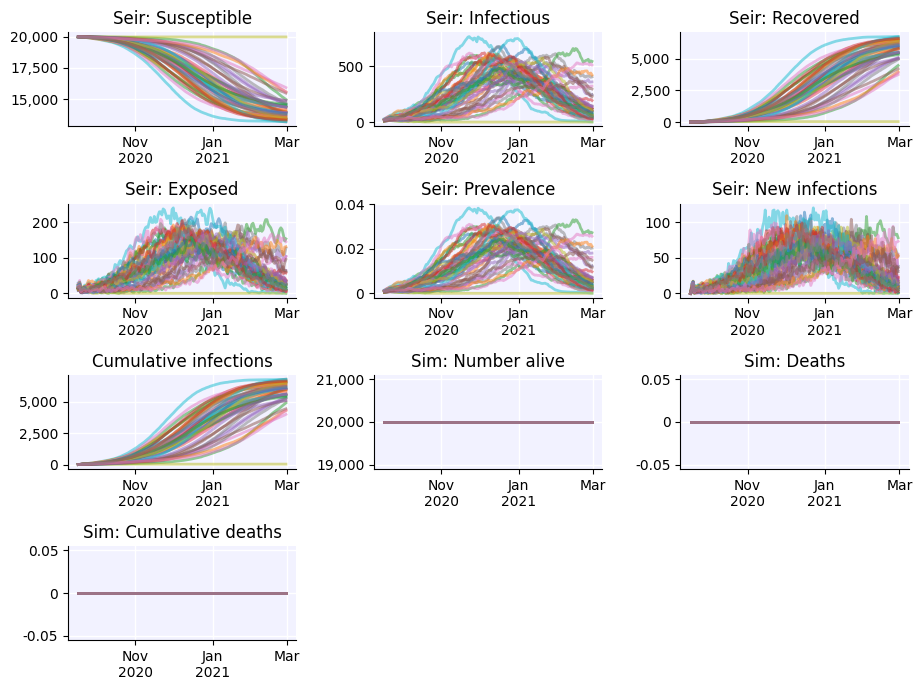

Figure(933.333x700)


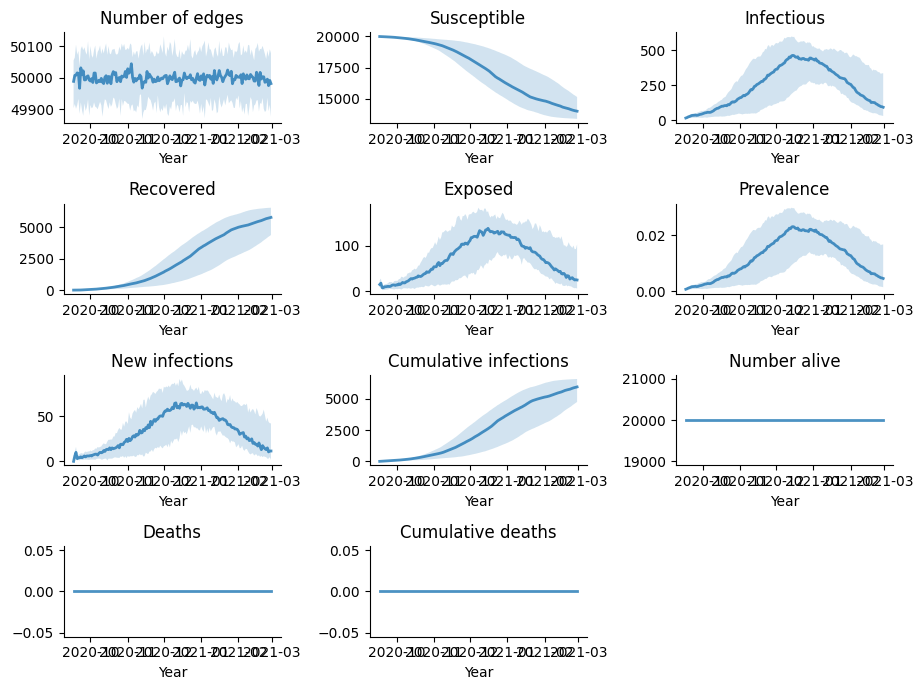

In [5]:
def seeding_return(self, sim, uids):
            p = np.zeros(len(uids))
            all_uids = ss.uids(sim.people)
            selected_uids = np.random.choice(all_uids, size = 2)
            p[selected_uids] = 1
            return p

pars = dict(
    n_agents = 20000,     # Number of agents to simulate
    networks = dict(      # *Networks* add detail on how the agents interact with each other
        type = 'random',  # Here, we use a 'random' network
        n_contacts = 5    # Each person has an average of 4 contacts with other people
    ),
    diseases = SEIR(init_prev = ss.bernoulli(p = 0.0007),
                                    beta = 0.039776887,
                                    dur_inf = ss.poisson(7), 
                                    p_death = 0),    
    start = sc.date('2020-09-17'),
        stop = sc.date('2021-02-28'),
        dt = 1,
        unit = 'day')


msim = ss.MultiSim(ss.Sim(pars), n_runs = 48)
msim.init_sims()
msim.run()

    # Plot individual sims
msim.plot()

    # Reduce and plot mean
msim.median()
msim.plot()



In [6]:
res_df = msim.results.to_df()
res_df

,timevec,randomnet_n_edges,randomnet_n_edges_low,randomnet_n_edges_high,timevec,seir_n_susceptible,seir_n_susceptible_low,seir_n_susceptible_high,timevec,seir_n_infected,...,n_alive_low,n_alive_high,timevec,new_deaths,new_deaths_low,new_deaths_high,timevec,cum_deaths,cum_deaths_low,cum_deaths_high
0,2020-09-17,49989.0,49904.1,50055.6,2020-09-17,19985.0,19975.7,19991.0,2020-09-17,15.0,...,20000.0,20000.0,2020-09-17,0.0,0.0,0.0,2020-09-17,0.0,0.0,0.0
1,2020-09-18,50008.0,49917.1,50065.1,2020-09-18,19982.0,19971.8,19988.6,2020-09-18,18.0,...,20000.0,20000.0,2020-09-18,0.0,0.0,0.0,2020-09-18,0.0,0.0,0.0
2,2020-09-19,50008.5,49902.0,50105.6,2020-09-19,19977.0,19967.1,19987.3,2020-09-19,23.0,...,20000.0,20000.0,2020-09-19,0.0,0.0,0.0,2020-09-19,0.0,0.0,0.0
3,2020-09-20,50016.0,49913.8,50073.7,2020-09-20,19972.0,19962.0,19984.6,2020-09-20,25.5,...,20000.0,20000.0,2020-09-20,0.0,0.0,0.0,2020-09-20,0.0,0.0,0.0
4,2020-09-21,50014.5,49933.3,50085.6,2020-09-21,19967.0,19953.7,19982.3,2020-09-21,29.5,...,20000.0,20000.0,2020-09-21,0.0,0.0,0.0,2020-09-21,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,2021-02-24,49988.5,49896.8,50060.2,2021-02-24,14095.0,13411.8,15401.7,2021-02-24,106.0,...,20000.0,20000.0,2021-02-24,0.0,0.0,0.0,2021-02-24,0.0,0.0,0.0
161,2021-02-25,49996.0,49936.5,50086.8,2021-02-25,14066.0,13406.4,15326.8,2021-02-25,102.0,...,20000.0,20000.0,2021-02-25,0.0,0.0,0.0,2021-02-25,0.0,0.0,0.0
162,2021-02-26,49975.5,49894.1,50067.1,2021-02-26,14042.0,13400.3,15272.7,2021-02-26,96.5,...,20000.0,20000.0,2021-02-26,0.0,0.0,0.0,2021-02-26,0.0,0.0,0.0
163,2021-02-27,49992.0,49914.8,50091.0,2021-02-27,14019.0,13393.4,15202.1,2021-02-27,95.5,...,20000.0,20000.0,2021-02-27,0.0,0.0,0.0,2021-02-27,0.0,0.0,0.0


In [7]:
res_df.to_csv("/Users/nparke19/Documents/Mobility/Alpha_wave/Starsim_sims/Penn_even_mobility_fit_no_mob_sims.csv", index=False)

In [8]:
ss.Result(msim, summarize_by='mean')

TypeError: can only concatenate str (not "MultiSim") to str

Initializing sim with 100000 agents
  Running 2020.09.17 ( 0/165) (0.00 s)  ———————————————————— 1%
  Running 2020.09.27 (10/165) (0.23 s)  •——————————————————— 7%
  Running 2020.10.07 (20/165) (0.46 s)  ••—————————————————— 13%
  Running 2020.10.17 (30/165) (0.69 s)  •••————————————————— 19%
  Running 2020.10.27 (40/165) (0.92 s)  ••••———————————————— 25%
  Running 2020.11.06 (50/165) (1.17 s)  ••••••—————————————— 31%
  Running 2020.11.16 (60/165) (1.40 s)  •••••••————————————— 37%
  Running 2020.11.26 (70/165) (1.62 s)  ••••••••———————————— 43%
  Running 2020.12.06 (80/165) (1.85 s)  •••••••••——————————— 49%
  Running 2020.12.16 (90/165) (2.07 s)  •••••••••••————————— 55%
  Running 2020.12.26 (100/165) (2.29 s)  ••••••••••••———————— 61%
  Running 2021.01.05 (110/165) (2.52 s)  •••••••••••••——————— 67%
  Running 2021.01.15 (120/165) (2.74 s)  ••••••••••••••—————— 73%
  Running 2021.01.25 (130/165) (2.96 s)  •••••••••••••••————— 79%
  Running 2021.02.04 (140/165) (3.19 s)  •••••••••••

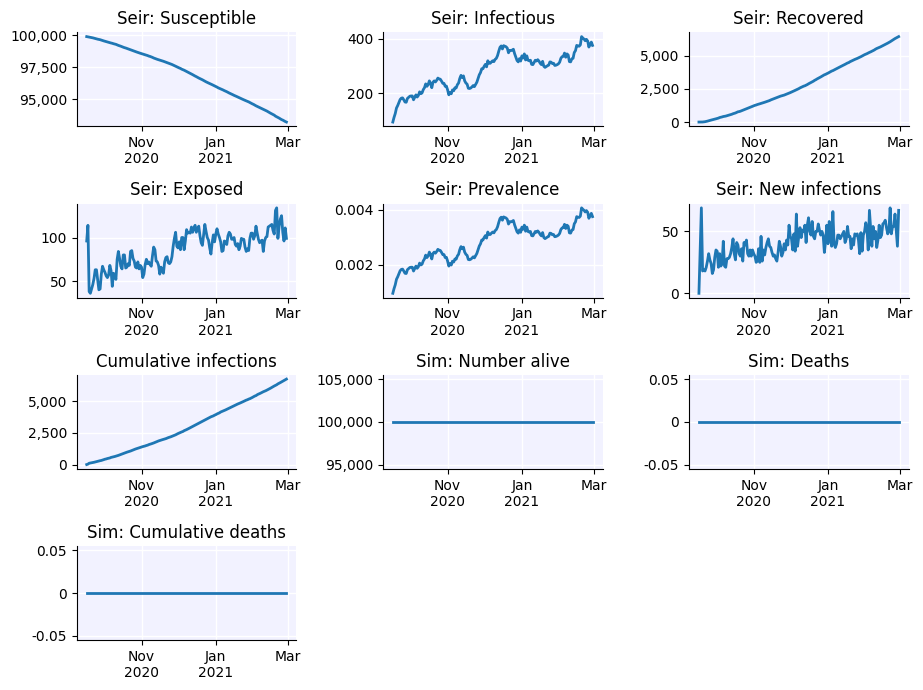

In [9]:
def seeding_return(self, sim, uids):
            p = np.zeros(len(uids))
            all_uids = ss.uids(sim.people)
            selected_uids = np.random.choice(all_uids, size = 2)
            p[selected_uids] = 1
            return p

pars = dict(
    n_agents = 100000,     # Number of agents to simulate
    networks = dict(      # *Networks* add detail on how the agents interact with each other
        type = 'random',  # Here, we use a 'random' network
        n_contacts = 5    # Each person has an average of 4 contacts with other people
    ),
    diseases = SEIR(init_prev = ss.bernoulli(p = 0.0007),
                                    beta = 0.03433549887476396,
                                    dur_inf = ss.poisson(7), 
                                    p_death = 0),    
    start = sc.date('2020-09-17'),
        stop = sc.date('2021-02-28'),
        dt = 1,
        unit = 'day')


sim = ss.Sim(pars)
sim.run()

    # Plot individual sims
sim.plot()


In [10]:
sim.results.timevec

array([<2020.09.17>, <2020.09.18>, <2020.09.19>, <2020.09.20>,
       <2020.09.21>, <2020.09.22>, <2020.09.23>, <2020.09.24>,
       <2020.09.25>, <2020.09.26>, <2020.09.27>, <2020.09.28>,
       <2020.09.29>, <2020.09.30>, <2020.10.01>, <2020.10.02>,
       <2020.10.03>, <2020.10.04>, <2020.10.05>, <2020.10.06>,
       <2020.10.07>, <2020.10.08>, <2020.10.09>, <2020.10.10>,
       <2020.10.11>, <2020.10.12>, <2020.10.13>, <2020.10.14>,
       <2020.10.15>, <2020.10.16>, <2020.10.17>, <2020.10.18>,
       <2020.10.19>, <2020.10.20>, <2020.10.21>, <2020.10.22>,
       <2020.10.23>, <2020.10.24>, <2020.10.25>, <2020.10.26>,
       <2020.10.27>, <2020.10.28>, <2020.10.29>, <2020.10.30>,
       <2020.10.31>, <2020.11.01>, <2020.11.02>, <2020.11.03>,
       <2020.11.04>, <2020.11.05>, <2020.11.06>, <2020.11.07>,
       <2020.11.08>, <2020.11.09>, <2020.11.10>, <2020.11.11>,
       <2020.11.12>, <2020.11.13>, <2020.11.14>, <2020.11.15>,
       <2020.11.16>, <2020.11.17>, <2020.11.18>, <2020.

In [11]:
# Convert to list of (ss.date, value) tuples

expected = pd.read_csv("~/Desktop/maryland_inc_rates2.csv")

# Convert to list of (ss.date, value) tuples
expected_df = [(ss.date(row['time_value']), row['cases']) for _, row in expected.iterrows()]
expected_df

[(<2020.10.01>, 43.759687),
 (<2020.10.02>, 45.564332),
 (<2020.10.03>, 45.3756105),
 (<2020.10.04>, 45.8474135),
 (<2020.10.05>, 46.130495),
 (<2020.10.06>, 45.9181835),
 (<2020.10.07>, 46.4607565),
 (<2020.10.08>, 46.177675),
 (<2020.10.09>, 46.4371665),
 (<2020.10.10>, 46.897174),
 (<2020.10.11>, 47.970525),
 (<2020.10.12>, 48.00591),
 (<2020.10.13>, 48.81976950000001),
 (<2020.10.14>, 50.1762015),
 (<2020.10.15>, 48.6310485),
 (<2020.10.16>, 49.1854165),
 (<2020.10.17>, 51.0962165),
 (<2020.10.18>, 50.718774499999995),
 (<2020.10.19>, 50.636209),
 (<2020.10.20>, 51.910076),
 (<2020.10.21>, 50.931086),
 (<2020.10.22>, 52.263928),
 (<2020.10.23>, 51.4500685),
 (<2020.10.24>, 51.4264785),
 (<2020.10.25>, 54.516785),
 (<2020.10.26>, 55.3188495),
 (<2020.10.27>, 58.939934),
 (<2020.10.28>, 61.2045865),
 (<2020.10.29>, 63.787705499999994),
 (<2020.10.30>, 66.323644),
 (<2020.10.31>, 68.3406),
 (<2020.11.01>, 69.18984449999999),
 (<2020.11.02>, 72.551438),
 (<2020.11.03>, 71.06526),
 (<20

In [12]:
for date, expected_prev in expected_df:
    print(date)

2020.10.01
2020.10.02
2020.10.03
2020.10.04
2020.10.05
2020.10.06
2020.10.07
2020.10.08
2020.10.09
2020.10.10
2020.10.11
2020.10.12
2020.10.13
2020.10.14
2020.10.15
2020.10.16
2020.10.17
2020.10.18
2020.10.19
2020.10.20
2020.10.21
2020.10.22
2020.10.23
2020.10.24
2020.10.25
2020.10.26
2020.10.27
2020.10.28
2020.10.29
2020.10.30
2020.10.31
2020.11.01
2020.11.02
2020.11.03
2020.11.04
2020.11.05
2020.11.06
2020.11.07
2020.11.08
2020.11.09
2020.11.10
2020.11.11
2020.11.12
2020.11.13
2020.11.14
2020.11.15
2020.11.16
2020.11.17
2020.11.18
2020.11.19
2020.11.20
2020.11.21
2020.11.22
2020.11.23
2020.11.24
2020.11.25
2020.11.26
2020.11.27
2020.11.28
2020.11.29
2020.11.30
2020.12.01
2020.12.02
2020.12.03
2020.12.04
2020.12.05
2020.12.06
2020.12.07
2020.12.08
2020.12.09
2020.12.10
2020.12.11
2020.12.12
2020.12.13
2020.12.14
2020.12.15
2020.12.16
2020.12.17
2020.12.18
2020.12.19
2020.12.20
2020.12.21
2020.12.22
2020.12.23
2020.12.24
2020.12.25
2020.12.26
2020.12.27
2020.12.28
2020.12.29
2020.12.30

In [13]:

ind = np.searchsorted(sim.results.timevec, ss.date("2020.10.01"), side='left')
ind

sim_prev = sim.results.seir.n_infected[ind]
sim_prev



190.0